# ADNI Dataset Notebook
This notebook demonstrates that our group understands the ADNI data structure, labels, longitudinal setup, and preprocessing context before model training.

## What we verify
- How metadata CSVs map to MRI files
- How visits are represented across time
- Class and demographic distributions
- A leakage-safe train/test split at the subject level

### Group Members:
- Muhammad Ahmad Sarfraz 27100345
- Fatima Nauman 27100231

## 1) Import Libraries
We use medical image IO, tabular analysis, and visualization libraries to inspect ADNI metadata and MRI volumes.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

## 2) Load Sample Metadata
We read the ADNI sample CSV and verify subject-level metadata needed to connect scans, visits, and labels.

In [2]:
csv_path = Path(r"C:\Users\HP\Desktop\adni\ADNI1_Complete_1Yr_1.5T_4_06_2026.csv")
df = pd.read_csv(csv_path)
df = df.dropna(subset=['Subject'])
print(df)

  Image Data ID     Subject Group Sex   Age Visit Modality  \
0        I97327  941_S_1311   MCI   M  69.0    sc      MRI   
1        I97341  941_S_1311   MCI   M  70.0   m06      MRI   
2       I112538  941_S_1311   MCI   M  70.0   m12      MRI   

                                  Description           Type   Acq Date  \
0    MPR; GradWarp; B1 Correction; N3; Scaled  Pre-processed   3/2/2007   
1  MPR-R; GradWarp; B1 Correction; N3; Scaled  Pre-processed  9/27/2007   
2    MPR; GradWarp; B1 Correction; N3; Scaled  Pre-processed   6/1/2008   

  Format Downloaded  
0  NiFTI        Yes  
1  NiFTI        Yes  
2  NiFTI        Yes  


## 3) Discover MRI Volumes
We locate all downloaded .nii files and confirm the folder organization of ADNI scans.

In [3]:
base_path = Path(r"C:\Users\HP\Desktop\adni\ADNI1_Complete 1Yr 1.5T\ADNI")
nii_files = sorted(base_path.glob("**/*.nii"))
for f in nii_files:
    print(f)

C:\Users\HP\Desktop\adni\ADNI1_Complete 1Yr 1.5T\ADNI\941_S_1311\MPR-R__GradWarp__B1_Correction__N3__Scaled\2007-09-27_15_35_45.0\I97341\ADNI_941_S_1311_MR_MPR-R__GradWarp__B1_Correction__N3__Scaled_Br_20080313131733540_S40710_I97341.nii
C:\Users\HP\Desktop\adni\ADNI1_Complete 1Yr 1.5T\ADNI\941_S_1311\MPR__GradWarp__B1_Correction__N3__Scaled\2007-03-02_15_49_04.0\I97327\ADNI_941_S_1311_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080313130949784_S27408_I97327.nii
C:\Users\HP\Desktop\adni\ADNI1_Complete 1Yr 1.5T\ADNI\941_S_1311\MPR__GradWarp__B1_Correction__N3__Scaled\2008-06-01_15_31_27.0\I112538\ADNI_941_S_1311_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080703170241434_S51039_I112538.nii


## 4) Map Image IDs to Visits and Load Scans
We match each MRI scan to its visit label (for example sc, m06, m12) and inspect image shapes to validate consistency.

In [4]:
# Map image IDs to timepoints from our CSV
id_to_visit = dict(zip(df['Image Data ID'], df['Visit']))

scans = []
for f in nii_files:
    image_id = f.parent.name  # folder name is the image ID e.g. I97327
    visit = id_to_visit.get(image_id, 'unknown')
    img = nib.load(str(f))
    data = img.get_fdata()
    scans.append({
        'file': f,
        'image_id': image_id,
        'visit': visit,
        'data': data,
        'shape': data.shape
    })
    print(f"Loaded {image_id} | Visit: {visit} | Shape: {data.shape}")

Loaded I97341 | Visit: m06 | Shape: (192, 192, 160)
Loaded I97327 | Visit: sc | Shape: (192, 192, 160)
Loaded I112538 | Visit: m12 | Shape: (192, 192, 160)


## 5) Visualize Longitudinal MRI Slices
We visualize axial, coronal, and sagittal mid-slices across timepoints for one subject to verify longitudinal progression data exists.

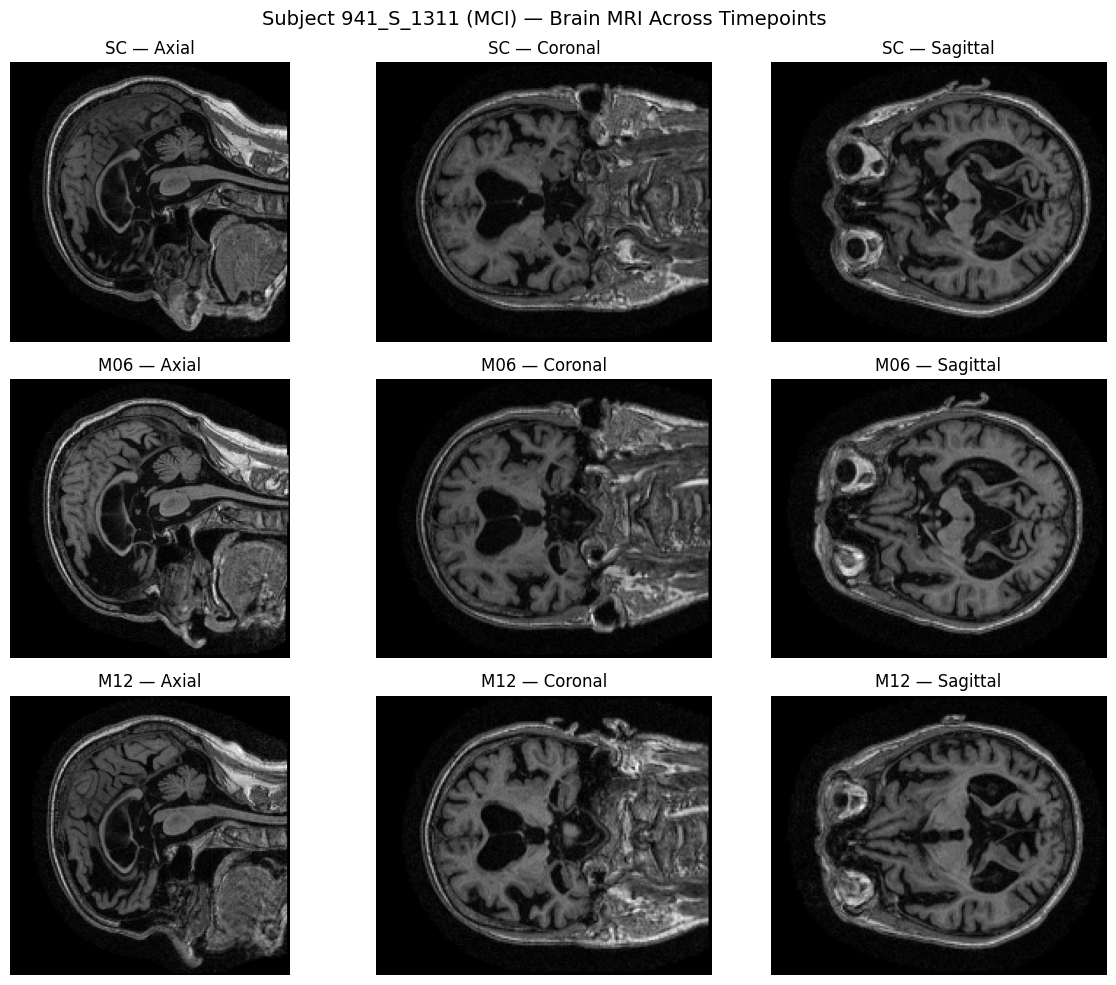

In [5]:
# Sort by visit order
visit_order = {'sc': 0, 'm06': 1, 'm12': 2}
scans_sorted = sorted(scans, key=lambda x: visit_order.get(x['visit'], 99))

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Subject 941_S_1311 (MCI) — Brain MRI Across Timepoints', fontsize=14)

views = ['Axial', 'Coronal', 'Sagittal']

for row, scan in enumerate(scans_sorted):
    data = scan['data']
    mid = [s // 2 for s in data.shape]
    slices = [
        data[:, :, mid[2]],   # axial
        data[:, mid[1], :],   # coronal
        data[mid[0], :, :]    # sagittal
    ]
    for col, (sl, view) in enumerate(zip(slices, views)):
        axes[row, col].imshow(sl.T, cmap='gray', origin='lower')
        axes[row, col].set_title(f"{scan['visit'].upper()} — {view}")
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 6) Full ADNI Cohort
Note: In the previous cells, we used only 1 MCI subject for demonstration purposes. In the actual project, we will be using a large chunk of the dataset, with overall cohort statistics (subjects, scans, classes, age, sex, visits) provided below to justify dataset suitability.

In [ ]:
full_df = pd.read_csv(r"C:\Users\HP\Desktop\adni\MPRAGE_4_06_2026.csv")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total scans: {len(full_df)}")
print(f"Total unique subjects: {full_df['Subject'].nunique()}")

print(f"\nDiagnosis Groups (Classes):")
print(full_df['Group'].value_counts().to_string())

print(f"\nSex Distribution:")
print(full_df[['Subject','Sex']].drop_duplicates()['Sex'].value_counts().to_string())

print(f"\nAge Statistics:")
age_df = full_df[['Subject','Age']].drop_duplicates()
print(f"  Mean age:  {age_df['Age'].mean():.1f}")
print(f"  Std:       {age_df['Age'].std():.1f}")
print(f"  Min age:   {age_df['Age'].min()}")
print(f"  Max age:   {age_df['Age'].max()}")

print(f"\nVisit Timepoints available:")
print(full_df['Visit'].value_counts().to_string())

print(f"\nOur downloaded sample: 1 MCI subject, 3 timepoints (sc, m06, m12)")

ADNI FULL DATASET OVERVIEW
Total scans: 11642
Total unique subjects: 1268

Diagnosis Groups (Classes):
Group
CN      3316
MCI     3153
EMCI    2230
AD      1484
LMCI    1176
SMC      283

Sex Distribution:
Sex
M    674
F    593
X      1

Age Statistics:
  Mean age:  75.3
  Std:       7.4
  Min age:   55
  Max age:   96

Visit Timepoints available:
Visit
v02      1266
v11      1224
m06      1144
v21      1001
v04       998
v05       930
m12       871
sc        787
m24       704
v41       428
m36       424
m18       365
v06       351
bl        290
v31       226
scmri     200
m48       179
m03       167
m60        42
v51        31
nv          6
tau         4
init        2
uns1        2

Our downloaded sample: 1 MCI subject, 3 timepoints (sc, m06, m12)


## 7) Visual Sanity Checks of Cohort Statistics
These plots make class balance, demographic distribution, and age spread easy to interpret at a glance.

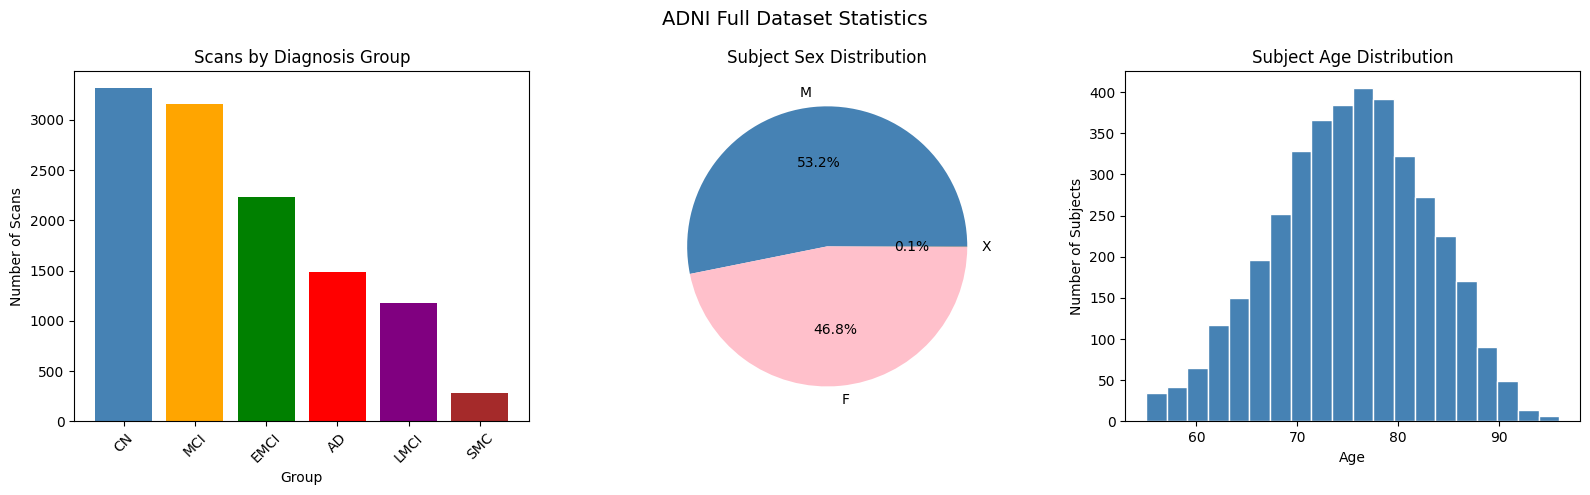

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ADNI Full Dataset Statistics', fontsize=14)

# Plot 1 - Diagnosis group distribution
group_counts = full_df['Group'].value_counts()
axes[0].bar(group_counts.index, group_counts.values, color=['steelblue','orange','green','red','purple','brown'])
axes[0].set_title('Scans by Diagnosis Group')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Number of Scans')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 - Sex distribution
sex_counts = full_df[['Subject','Sex']].drop_duplicates()['Sex'].value_counts()
axes[1].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', colors=['steelblue','pink','gray'])
axes[1].set_title('Subject Sex Distribution')

# Plot 3 - Age distribution
age_df = full_df[['Subject','Age']].drop_duplicates()
axes[2].hist(age_df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[2].set_title('Subject Age Distribution')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Number of Subjects')

plt.tight_layout()
plt.show()

## 8) Leakage-Safe Train/Test Split
We split by subject (not by scan) to prevent information leakage across visits of the same person.

In [8]:
from sklearn.model_selection import train_test_split

# Split at subject level to avoid data leakage
subjects = full_df[['Subject', 'Group']].drop_duplicates()
train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=42, stratify=subjects['Group'])

print("=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Total unique subjects: {len(subjects)}")
print(f"Train subjects: {len(train_subjects)} ({len(train_subjects)/len(subjects)*100:.0f}%)")
print(f"Test subjects:  {len(test_subjects)} ({len(test_subjects)/len(subjects)*100:.0f}%)")

print(f"\nTrain set diagnosis breakdown:")
print(train_subjects['Group'].value_counts().to_string())
print(f"\nTest set diagnosis breakdown:")
print(test_subjects['Group'].value_counts().to_string())

print(f"\nNote: Split is done at subject level to prevent data leakage")
print(f"across timepoints of the same subject.")

TRAIN / TEST SPLIT
Total unique subjects: 1268
Train subjects: 1014 (80%)
Test subjects:  254 (20%)

Train set diagnosis breakdown:
Group
CN      260
MCI     233
EMCI    189
AD      180
LMCI    105
SMC      47

Test set diagnosis breakdown:
Group
CN      66
MCI     58
EMCI    47
AD      45
LMCI    26
SMC     12

Note: Split is done at subject level to prevent data leakage
across timepoints of the same subject.


## 9) Why ADNI Fits a Longitudinal Deep Learning Task
We highlight irregular visit timing, repeated measures per subject, and clinically relevant labels for progression modeling.

In [9]:
print("=" * 50)
print("DATASET FEATURES FOR TIME-AWARE TRANSFORMER")
print("=" * 50)

# Show temporal irregularity from our sample
import datetime

dates = {
    'sc':  '3/2/2007',
    'm06': '9/27/2007',
    'm12': '6/1/2008'
}

date_fmt = '%m/%d/%Y'
date_objects = {v: datetime.datetime.strptime(d, date_fmt) for v, d in dates.items()}
visits_sorted = ['sc', 'm06', 'm12']

print("\n1. TEMPORAL FEATURES (key for time-aware modelling):")
print(f"{'Visit':<8} {'Date':<15} {'Days from baseline':<20} {'Gap from prev visit'}")
print("-" * 65)
baseline = date_objects['sc']
prev = baseline
for v in visits_sorted:
    d = date_objects[v]
    from_baseline = (d - baseline).days
    gap = (d - prev).days
    print(f"{v:<8} {dates[v]:<15} {from_baseline:<20} {gap if v != 'sc' else 'N/A'}")
    prev = d

print("\n2. INPUT FEATURES PER SCAN:")
print(f"  - 3D MRI volume:     {scans[0]['shape']} voxels (H x W x D)")
print(f"  - Voxel resolution:  2mm isotropic (post-registration)")
print(f"  - Modality:          T1-weighted structural MRI")
print(f"  - Timestamp:         acquisition date per visit")
print(f"  - Time delta:        days between consecutive visits (irregular)")

print("\n3. LABEL / TARGET FEATURES:")
print(f"  - Diagnosis group:   MCI (target: predict conversion to AD)")
print(f"  - Conversion label:  binary (converter / stable MCI)")
print(f"  - Time-to-event:     days until conversion (for C-index evaluation)")

print("\n4. WHY THIS DATASET SUITS OUR TASK:")
print(f"  - 1,268 unique subjects with longitudinal follow-ups")
print(f"  - Irregular visit intervals (your model's core contribution)")
print(f"  - Variable sequence lengths (sc only up to m48+)")
print(f"  - MCI cohort present — the exact gap identified in literature")
print(f"  - Gold-standard benchmark used by all 11 surveyed papers")

DATASET FEATURES FOR TIME-AWARE TRANSFORMER

1. TEMPORAL FEATURES (key for time-aware modelling):
Visit    Date            Days from baseline   Gap from prev visit
-----------------------------------------------------------------
sc       3/2/2007        0                    N/A
m06      9/27/2007       209                  209
m12      6/1/2008        457                  248

2. INPUT FEATURES PER SCAN:
  - 3D MRI volume:     (192, 192, 160) voxels (H x W x D)
  - Voxel resolution:  2mm isotropic (post-registration)
  - Modality:          T1-weighted structural MRI
  - Timestamp:         acquisition date per visit
  - Time delta:        days between consecutive visits (irregular)

3. LABEL / TARGET FEATURES:
  - Diagnosis group:   MCI (target: predict conversion to AD)
  - Conversion label:  binary (converter / stable MCI)
  - Time-to-event:     days until conversion (for C-index evaluation)

4. WHY THIS DATASET SUITS OUR TASK:
  - 1,268 unique subjects with longitudinal follow-ups
 

## 10) Submission Readiness Note
This notebook section consolidates data provenance, annotation meaning, and preprocessing context used in our project setup.

In [10]:
print("=" * 50)
print("ANNOTATIONS & PROJECT CONTEXT")
print("=" * 50)
print("""
Classes (6 total):
  - CN   (Cognitively Normal)        — 3316 scans
  - MCI  (Mild Cognitive Impairment) — 3153 scans
  - EMCI (Early MCI)                 — 2230 scans
  - AD   (Alzheimer's Disease)       — 1484 scans
  - LMCI (Late MCI)                  — 1176 scans
  - SMC  (Significant Memory Concern)—  283 scans

Annotations:
  - Labels provided by ADNI at subject level (no custom annotations needed)
  - Each scan labelled with diagnosis group
  - Longitudinal timepoints allow modelling of progression over time
  - Key progression pathway: CN → SMC → EMCI → LMCI → MCI → AD

Preprocessing (applied by ADNI before download):
  - GradWarp correction
  - B1 non-uniformity correction  
  - N3 bias field correction
  - Scaled to standard intensity

Image properties:
  - Format: NIfTI (.nii)
  - Shape: 192 x 192 x 160 voxels
  - Modality: T1-weighted MRI
  - Total scans: 11,642 across 1,268 subjects

Train/Test Split:
  - 80% train (1,014 subjects), 20% test (254 subjects)
  - Split at subject level to prevent data leakage across timepoints
  - Stratified by diagnosis group to maintain class balance

Sample shown: Subject 941_S_1311 (MCI, Male)
  - Screening (sc)  — March 2007
  - 6 months (m06)  — September 2007  
  - 12 months (m12) — June 2008
""")

ANNOTATIONS & PROJECT CONTEXT

Classes (6 total):
  - CN   (Cognitively Normal)        — 3316 scans
  - MCI  (Mild Cognitive Impairment) — 3153 scans
  - EMCI (Early MCI)                 — 2230 scans
  - AD   (Alzheimer's Disease)       — 1484 scans
  - LMCI (Late MCI)                  — 1176 scans
  - SMC  (Significant Memory Concern)—  283 scans

Annotations:
  - Labels provided by ADNI at subject level (no custom annotations needed)
  - Each scan labelled with diagnosis group
  - Longitudinal timepoints allow modelling of progression over time
  - Key progression pathway: CN → SMC → EMCI → LMCI → MCI → AD

Preprocessing (applied by ADNI before download):
  - GradWarp correction
  - B1 non-uniformity correction  
  - N3 bias field correction
  - Scaled to standard intensity

Image properties:
  - Format: NIfTI (.nii)
  - Shape: 192 x 192 x 160 voxels
  - Modality: T1-weighted MRI
  - Total scans: 11,642 across 1,268 subjects

Train/Test Split:
  - 80% train (1,014 subjects), 20% test